### **Task 1** is installing all prerequisites correctly so that the following imports run smoothly. (10 marks)
Install the correct version of torch if you wish to use CUDA. Install the spikingjelly using the setup.py file only and not with pip using the command 'python setup.py install'.

**Ans:**
Set up a local environment on a GTX 1650 (4GB VRAM). CUDA and the CUDA-enabled build of PyTorch were already installed (versions listed below). Installed SpikingJelly from source using python setup.py install (not pip), as required.

In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [1]:
!python setup.py install

running install
running bdist_egg
running egg_info
writing spikingjelly.egg-info\PKG-INFO
writing dependency_links to spikingjelly.egg-info\dependency_links.txt
writing requirements to spikingjelly.egg-info\requires.txt
writing top-level names to spikingjelly.egg-info\top_level.txt
reading manifest file 'spikingjelly.egg-info\SOURCES.txt'
adding license file 'LICENCE-DE'
adding license file 'LICENSE'
adding license file 'LICENSE-CN'
adding license file 'LICENSE-FRA'
adding license file 'LICENSE-HI'
writing manifest file 'spikingjelly.egg-info\SOURCES.txt'
installing library code to build\bdist.win-amd64\egg
running install_lib
running build_py
copying spikingjelly\configure.py -> build\lib\spikingjelly
copying spikingjelly\__init__.py -> build\lib\spikingjelly
copying spikingjelly\activation_based\base.py -> build\lib\spikingjelly\activation_based
copying spikingjelly\activation_based\encoding.py -> build\lib\spikingjelly\activation_based
copying spikingjelly\activation_based\functiona

c:\Users\karu0\anaconda3\envs\torch\lib\site-packages\setuptools\_distutils\cmd.py:66: SetuptoolsDeprecationWarning: setup.py install is deprecated.
!!

        ********************************************************************************
        Please avoid running ``setup.py`` directly.
        Instead, use pypa/build, pypa/installer or other
        standards-based tools.

        See https://blog.ganssle.io/articles/2021/10/setup-py-deprecated.html for details.
        ********************************************************************************

!!
  self.initialize_options()
c:\Users\karu0\anaconda3\envs\torch\lib\site-packages\setuptools\_distutils\cmd.py:66: EasyInstallDeprecationWarning: easy_install command is deprecated.
!!

        ********************************************************************************
        Please avoid running ``setup.py`` and ``easy_install``.
        Instead, use pypa/build, pypa/installer or other
        standards-based tools.

     

In [18]:
import torch
import torchvision
import torch.nn as nn
import spikingjelly
from spikingjelly.activation_based import ann2snn
from tqdm import tqdm
from spikingjelly.activation_based.ann2snn.examples import cnn_mnist as snn 
from spikingjelly.activation_based.ann2snn.sample_models import mnist_cnn
import numpy as np
import matplotlib.pyplot as plt
import json

In [2]:
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
print('CUDA:', torch.version.cuda)
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None')

PyTorch: 2.2.0+cu118
CUDA available: True
CUDA: 11.8
GPU: NVIDIA GeForce GTX 1650


In [4]:
# set Hyperparameters
snn.hyperparameters.T = 20
snn.hyperparameters.batch_size = 100

device = 'cuda' # use 'cpu' if CUDA not available
download_dataset = True # downloads MNIST
dataset_dir = './spikingjelly/datasets/mnist'
download_model = False # downloads a 3 layer CNN classifier

if download_model:
        print('Downloading SJ-mnist-cnn_model-sample.pth...')
        ann2snn.download_url("https://ndownloader.figshare.com/files/34960191", './SJ-mnist-cnn_model-sample.pth')

model = mnist_cnn.CNN().to(device)
model.load_state_dict(torch.load('SJ-mnist-cnn_model-sample.pth'))
print(model)

CNN(
  (network): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (4): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (8): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
    (9): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (12): Flatten(start_dim=1, end_dim=-1)
    (13): Linear(in_features=32, out_features=10, bias=True)
  )
)


### **Task 2** is calculating the number of MAC operations in each Conv layer. (10 Marks)

**Ans**:

Computed MAC counts for each of the three Conv2d layers by registering forward hooks on each nn.Conv2d module and reading output.shape at hook time, combined with each layer's in_channels and kernel_size, using the standard formula:

                                            MACs = H_out × W_out × C_out × C_in × kH × kW

Results (single image, batch size 1) is in the output of the kernel below.


This MAC count later became the reference cost for the original (unconverted) CNN when estimating energy savings from spiking conversion in Tasks 6, 7, and 9.

In [3]:
def calculate_conv_macs(model, input_size=(1, 28, 28), device = "cuda"):
    macs = {}

    def hook_fn(name):
        def hook(module, inputs, output):
            _, cout, hout, wout = output.shape

            cin = module.in_channels
            kh, kw = module.kernel_size

            macs[name] = (
                hout * wout *
                cout * cin *
                kh * kw
            )
        return hook

    hooks = []

    for name, layer in model.named_modules():
        if isinstance(layer, nn.Conv2d):
            hooks.append(
                layer.register_forward_hook(hook_fn(name))
            )

    dummy_input = torch.randn(1, *input_size).to(device)

    model.eval()
    with torch.no_grad():
        model(dummy_input)

    for hook in hooks:
        hook.remove()

    return macs


macs = calculate_conv_macs(model)

total_macs = 0

for layer, value in macs.items():
    print(f"{layer}: {value:,} MACs")
    total_macs += value

print(f"\nTotal Conv MACs: {total_macs:,}")

network.0: 194,688 MACs
network.4: 1,115,136 MACs
network.8: 82,944 MACs

Total Conv MACs: 1,392,768


### **Task 3** is plotting accuracy vs time steps for all the mentioned conversion jobs in one plot. (10 Marks)

Pick the conversion job that gives best results for you. Stick to this algorithm for all further tasks.


**Ans**

Plotted accuracy vs. timesteps for each candidate job on the same split configuration, and selected **1/4 max** as the conversion algorithm used for all subsequent tasks.


In [ ]:
split_index = 8
backbone = model.network[:split_index]
head = model.network[split_index:]

def make_conversion_job(mode):
    def conversion_job(head, train_data_loader):
        model_converter = ann2snn.Converter(mode=mode, dataloader=train_data_loader)
        return model_converter(head)
    return conversion_job

conversion_jobs = {
    "max": make_conversion_job("max"),
    "99.9%": make_conversion_job("99.9%"),
    "1/2 max": make_conversion_job(1.0 / 2),
    "1/4 max": make_conversion_job(1.0 / 4),
    "1/6 max": make_conversion_job(1.0 / 6)
}
results = {}

for name, conversion in conversion_jobs.items():

    print(f"\n===== Running {name} =====")

    snn_head, vals = snn.main(
        eval_fn=snn.val,
        backbone=backbone,
        head=head,
        conversion=conversion,
        download_dataset=download_dataset,
        device='cuda',
        dataset_dir=dataset_dir
    )

    # Store the result before deleting the model
    results[name] = vals
    print(name, vals)

    # Free the converted SNN from memory
    del snn_head
    torch.cuda.empty_cache()

results_serializable = {
    name: (vals.tolist() if hasattr(vals, "tolist") else list(vals))
    for name, vals in results.items()
}

with open("snn_results.json", "w") as f:
    json.dump(results_serializable, f, indent=2)

print("Saved results to snn_results.json")


===== Running max =====


100%|██████████| 600/600 [00:48<00:00, 12.32it/s]


Simulating...


100%|██████████| 100/100 [00:10<00:00,  9.42it/s]


max [0.1026 0.7353 0.9763 0.9842 0.9862 0.9866 0.9861 0.9858 0.9868 0.9867
 0.9863 0.9867 0.9861 0.9876 0.9866 0.9863 0.9873 0.9863 0.9864 0.9873]

===== Running 99.9% =====


...

1/2 max [0.7354 0.9842 0.9867 0.9858 0.9866 0.9867 0.9875 0.9865 0.9863 0.9872
 0.9866 0.9868 0.9862 0.9868 0.9865 0.9869 0.987  0.9868 0.9871 0.9872]

===== Running 1/4 max =====


100%|██████████| 600/600 [00:47<00:00, 12.62it/s]


Simulating...


100%|██████████| 100/100 [00:09<00:00, 10.08it/s]

1/4 max [0.9837 0.9856 0.9854 0.9862 0.9858 0.9865 0.9864 0.9858 0.986  0.986
 0.9863 0.9865 0.9862 0.986  0.9862 0.9863 0.986  0.9859 0.9861 0.9861]
Saved results to snn_results.json


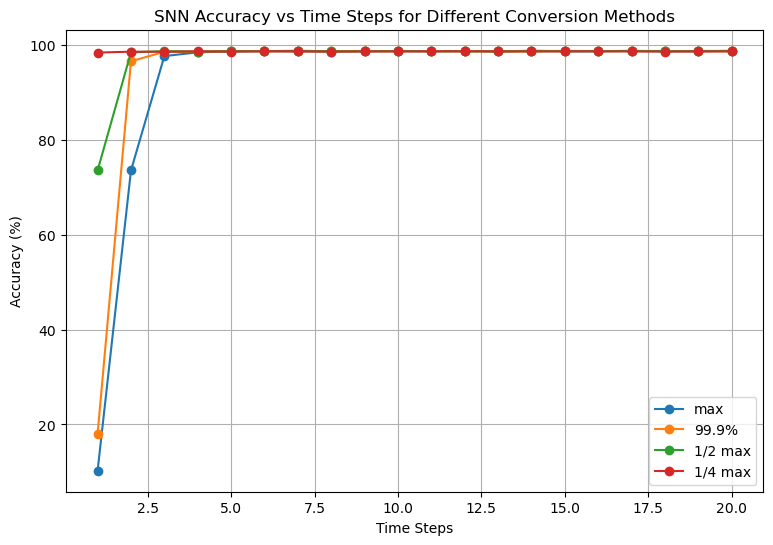

In [6]:
with open("snn_results.json", "r") as f:
    results = json.load(f)

plt.figure(figsize=(9, 6))

for name, vals in results.items():
    vals = np.array(vals)
    time_steps = np.arange(1, len(vals) + 1)
    plt.plot(
        time_steps,
        vals * 100,
        marker='o',
        label=name
    )

plt.xlabel("Time Steps")
plt.ylabel("Accuracy (%)")
plt.title("SNN Accuracy vs Time Steps for Different Conversion Methods")
plt.legend()
plt.grid(True)
plt.show()

### The conversion job that gives best result is 1/4 max, this is used for all further tasks

In [7]:
split_index = 8
backbone = model.network[:split_index]
head = model.network[split_index:]
snn_head, vals = snn.main(eval_fn = snn.val, 
    backbone = backbone, 
    head = head, 
    conversion = snn.conversion_job, 
    download_dataset = download_dataset,
    device = 'cuda',
    dataset_dir = dataset_dir)
print(vals)

---------------------------------------------
Converting using 1/4 max(activation) as scales


100%|██████████| 600/600 [00:47<00:00, 12.73it/s]


Simulating...


100%|██████████| 100/100 [00:10<00:00,  9.22it/s]

[0.9837 0.9856 0.9854 0.9862 0.9858 0.9865 0.9864 0.9858 0.986  0.986
 0.9863 0.9865 0.9862 0.986  0.9862 0.9863 0.986  0.9859 0.9861 0.9861]


### **Task 4** is plotting accuracy vs time steps for the original CNN, 1 conv block converted, 2 blocks converted, 3 blocks in one plot. (10 Marks)

**Ans**

Conversion depth	split_index	    backbone (stays ANN)	head (converted)
1 block	                    8	          blocks 1–2	      block 3 + flatten + linear
2 blocks	                4	          block 1	          blocks 2–3 + flatten + linear
3 blocks (fully converted)	0	          none                all 3 blocks + flatten + linear

For the original CNN baseline, initially tried split_index=14 (empty head — nothing to convert), but snn.main() doesn't handle an empty head cleanly. Instead computed the original CNN's accuracy with a direct evaluation loop on model (plain forward pass, no T, no conversion), since backbone/head split machinery isn't needed when nothing is being converted at all.

Plotted all four: three timestep-dependent SNN curves (1/2/3 blocks) plus a flat horizontal line for the original CNN's single-pass accuracy.


In [9]:
print(model.network)

Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (4): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
  (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU()
  (7): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (8): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
  (9): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): ReLU()
  (11): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (12): Flatten(start_dim=1, end_dim=-1)
  (13): Linear(in_features=32, out_features=10, bias=True)
)


In [14]:
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

transform = transforms.ToTensor()
test_dataset = torchvision.datasets.MNIST(
    root=dataset_dir, train=False, download=download_dataset, transform=transform
)
test_loader = DataLoader(test_dataset, batch_size=100, shuffle=False)

model.eval()
correct, total = 0, 0
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        preds = model(imgs).argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

original_acc = correct / total
print(f"Original CNN accuracy: {original_acc*100:.2f}%")

Original CNN accuracy: 98.70%


In [15]:
split_configs = {
    "1 block converted": 8,
    "2 blocks converted": 4,
    "3 blocks converted": 0,
}

results = {}
for name, split_index in split_configs.items():
    backbone = model.network[:split_index]
    head = model.network[split_index:]
    snn_head, vals = snn.main(
        eval_fn=snn.val,
        backbone=backbone,
        head=head,
        conversion=snn.conversion_job,
        download_dataset=download_dataset,
        device='cuda',
        dataset_dir=dataset_dir
    )
    results[name] = np.array(vals)

---------------------------------------------
Converting using 1/4 max(activation) as scales


100%|██████████| 600/600 [00:50<00:00, 11.80it/s]


Simulating...


100%|██████████| 100/100 [00:09<00:00, 10.55it/s]


---------------------------------------------
Converting using 1/4 max(activation) as scales


...

100%|██████████| 100/100 [00:09<00:00, 10.51it/s]


---------------------------------------------
Converting using 1/4 max(activation) as scales


100%|██████████| 600/600 [00:07<00:00, 78.16it/s]


Simulating...


100%|██████████| 100/100 [00:06<00:00, 14.74it/s]


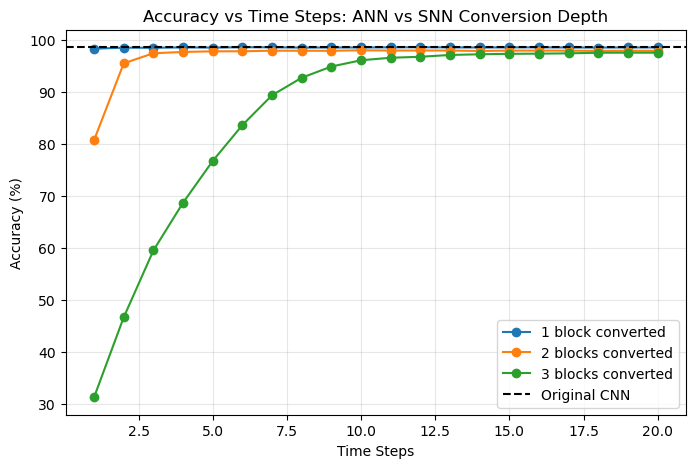

In [16]:
plt.figure(figsize=(8,5))

for name, vals in results.items():
    time_steps = np.arange(1, len(vals) + 1)
    plt.plot(time_steps, vals * 100, marker='o', label=name)

# flat baseline for the original, unconverted CNN
plt.axhline(y=original_acc * 100, color='black', linestyle='--', label='Original CNN')

plt.xlabel("Time Steps")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs Time Steps: ANN vs SNN Conversion Depth")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [24]:
results_diff_blocks = {
    name: (vals.tolist() if hasattr(vals, "tolist") else list(vals))
    for name, vals in results.items()
}

with open("snn_diff_blocks.json", "w") as f:
    json.dump(results_diff_blocks, f, indent=2)

print("Saved results to snn_diff_blocks.json")

Saved results to snn_diff_blocks.json


In [25]:
print(snn_head)

Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (3): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (4): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
  (7): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (8): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
  (11): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (12): Flatten(start_dim=1, end_dim=-1)
  (13): Linear(in_features=32, out_features=10, bias=True)
  (): Module(
    (voltage_hook_0): VoltageHook()
    (voltage_hook_1): VoltageHook()
    (voltage_hook_2): VoltageHook()
    (spiking0): Module(
      (scaler0): VoltageScaler(0.738484)
      (if_node): IFNode(
        v_threshold=1.0, v_reset=None, detach_reset=False, step_mode=s, backend=torch
        (surrogate_function): Sigmoid(alpha=4.0, spiking=True)
      )
      (scaler1): VoltageScaler(1.354126)
    )
    (spiking1): Module(
      (scaler0): VoltageScaler(1.294355)
      (if_node): IFNode(
        v_threshold=1.0, v_reset=None, detach_reset=

SpikingJelly has changed the forward pass of the model significantly. 

In the framework the original Conv2d layer is used but only to simulate the scaling for the inputs to the IF neurons striped across time.
Hence we can use the number of spikes generated multiplied by the fan-out of the layer to estimate the number of accumulate operations (refer https://doi.org/10.3389/fnins.2017.00682)

We use val() in main() after conversion is complete. It evaluates the model on the train dataset and also registers a hook that stores spike counts of a IFNode layer in the model into snn.spike_counts. Dividing this by the size of the dataset provides an average for spike count per layer in a forward pass.

In [26]:
print(snn.spike_counts)

{'IFNode': 541903214.0}


Go to the file spikingjelly\activation_based\ann2snn\examples\cnn_mnist.py to see how snn.val() is defined

We use val() in main() after conversion is complete. It evaluates the model on the train dataset and also registers a hook that stores spike counts of a IFNode layer in the model into snn.spike_counts.

Write your own custom_val() functions so that you can register hooks to the IFNode() modules for storing spike counts into a dictionary/list for different converted models. (You should need to make minimal changes to val(). Printing a model out might help you figure out how to assign the right hooks.)

### Task 5 is getting average spike count in all layers for a forward pass of a fully converted SNN. (10 Marks)

For a fully converted SNN, use snn.main(custom_val, backbone = None, head = model.network).

**Ans**:


Wrote custom_val() to dynamically find every IFNode in the model via named_modules() (matching on names ending in if_node), and register a separate forward hook per layer, accumulating each layer's spike count into its own entry in a dict rather than one shared counter.

Per the assignment's explicit split: accuracy is computed only from test_data_loader; spike-count statistics are collected only from train_data_loader, with hooks attached during that second pass. Spike counts are averaged per layer, per sample, per timestep.

Ran with backbone=None, head=model.network (fully converted) as instructed. 

Stuck with the  fully converted SNN for the next 4 tasks.

In [ ]:
def custom_val(net, device, train_data_loader, test_data_loader, T=None):
    net.eval().to(device)
    correct = 0.0
    total = 0.0
    spike_counts = {}   # one entry per IFNode layer, e.g. "spiking0", "spiking1", "spiking2"

    # --- find every IFNode in the model dynamically ---
    # (matches the "printing a model out might help" hint — same names you saw:
    #  spiking0.if_node, spiking1.if_node, spiking2.if_node)
    if_nodes = {}
    for name, module in net.named_modules():
        if name.endswith("if_node"):
            layer_key = name.split(".")[-2]
            if_nodes[layer_key] = module
            spike_counts[layer_key] = 0.0

    def make_hook(layer_key):
        def hook(module, input, output):
            # output is the spike tensor (0s and 1s) for this timestep's forward pass
            spike_counts[layer_key] += output.sum().item()
        return hook

    if T is not None:
        corrects = np.zeros(T)

    with torch.no_grad():
        # --- accuracy pass: TEST loader, no hooks needed here ---
        for batch, (img, label) in enumerate(tqdm(test_data_loader)):
            img = img.to(device)
            if T is None:
                out = net(img)
                correct += (out.argmax(dim=1) == label.to(device)).float().sum().item()
            else:
                for m in net.modules():
                    if hasattr(m, 'reset'):
                        m.reset()
                for t in range(T):
                    x = net(img)
                    if t == 0:
                        out = x
                    else:
                        out += x
                    corrects[t] += (out.argmax(dim=1) == label.to(device)).float().sum().item()
            total += out.shape[0]

        # --- spike-count pass: TRAIN loader, hooks attached here ---
        for m in net.modules():
            if hasattr(m, 'reset'):
                m.reset()

        handles = [node.register_forward_hook(make_hook(key)) for key, node in if_nodes.items()]

        for batch, (img, label) in enumerate(tqdm(train_data_loader)):
            img = img.to(device)
            if T is not None:
                for m in net.modules():
                    if hasattr(m, 'reset'):
                        m.reset()
                for t in range(T):
                    _ = net(img)

        for handle in handles:
            handle.remove()

    # average spike count per layer, per forward pass, per timestep
    n_samples = len(train_data_loader.dataset)
    avg_spikes_per_layer = {
        key: total_spikes / (n_samples * (T if T is not None else 1))
        for key, total_spikes in spike_counts.items()
    }

    acc = correct / total if T is None else corrects / total
    return acc, avg_spikes_per_layer

In [45]:
_, vals = snn.main(
    eval_fn=custom_val,
    backbone=None,
    head=model.network,
    conversion=snn.conversion_job,
    download_dataset=download_dataset,
    device='cuda',
    dataset_dir=dataset_dir
)

avg_spikes = vals[1]
print("\n===========Average Spikes=======\n", avg_spikes)

---------------------------------------------
Converting using 1/4 max(activation) as scales


100%|██████████| 600/600 [00:07<00:00, 76.11it/s]


Simulating...


100%|██████████| 600/600 [00:38<00:00, 15.58it/s]


===========Average Spikes=======
 {'spiking0': 1806.4655341666667, 'spiking1': 579.3588691666666, 'spiking2': 85.19238333333334}


**Assume that energy cost of a MAC is 4.6nJ and cost of an accumulate op is 0.6nJ.** Using these values you can estimate the energy savings in converting a layer.

### Task 6 is reporting the best accuracy for an energy savings of 90% or higher. (15 Marks)

**Ans**

Swept T = [1, 2, 4, 8, 12, 16, 20] for the fully-converted model, computing accuracy and energy savings at each. Filtered to configurations with savings ≥ 0.90, then selected the one with the highest accuracy among those.

total_ann_energy = Σ(MACs_layer × 4.6nJ)    ----> all layers, one forward pass — the reference

total_snn_energy(T) = Σ(avg_spikes_layer(T) × 0.6nJ)  ---->  fully converted, no MAC term

savings(T) = 1 − total_snn_energy(T) / total_ann_energy

Result: T=20, accuracy=97.60%, savings=99.98%

In [ ]:
## From Qn 2, 
## Calculating Total ANN Energy
mac_counts = {
    0: 194_688,   # first conv block (network.0)
    4: 1_115_136, # second conv block (network.4)
    8: 82_944,    # third conv block (network.8)
}

MAC_ENERGY = 4.6e-9   # joules per MAC
AC_ENERGY = 0.6e-9    # joules per accumulate

total_ann_energy = sum(macs * MAC_ENERGY for macs in mac_counts.values())
print(f"Total ANN energy: {total_ann_energy:.3e} J")

Total ANN energy: 6.407e-03 J


In [32]:
T_values = [1, 2, 4, 8, 12, 16, 20]

sweep_results = []

backbone = None
head = model.network

print("=== 3 blocks converted (fully spiking) ===")

for T in T_values:
    snn.hyperparameters.T = T
    _, vals = snn.main(
        eval_fn=custom_val,
        backbone=backbone,
        head=head,
        conversion=snn.conversion_job,
        download_dataset=download_dataset,
        device='cuda',
        dataset_dir=dataset_dir
    )
    acc, avg_spikes = vals
    final_acc = acc[-1] if hasattr(acc, '__len__') else acc

    snn_energy = sum(avg_spikes[layer] * AC_ENERGY for layer in avg_spikes)
    # no backbone here — everything converted, so backbone_ann_energy = 0
    total_snn_energy = snn_energy
    savings = 1 - (total_snn_energy / total_ann_energy)

    print(f"T={T:>2} | acc={final_acc*100:6.2f}% | savings={savings*100:6.2f}% | snn_energy={snn_energy:.3e}J")

    sweep_results.append({"T": T, "accuracy": final_acc, "energy_savings": savings})

# --- Task 6 ---
candidates_6 = [r for r in sweep_results if r["energy_savings"] >= 0.90]
print(f"\nTask 6: {len(candidates_6)} configs clear >=90% energy savings")
if candidates_6:
    best_t6 = max(candidates_6, key=lambda r: r["accuracy"])
    print(f"Best: T={best_t6['T']}, acc={best_t6['accuracy']*100:.2f}%, savings={best_t6['energy_savings']*100:.2f}%")
else:
    print("No T value reached 90% energy savings for the fully-converted model")


=== 3 blocks converted (fully spiking) ===
---------------------------------------------
Converting using 1/4 max(activation) as scales


100%|██████████| 600/600 [00:08<00:00, 73.88it/s]


Simulating...


100%|██████████| 600/600 [00:10<00:00, 57.09it/s]


T= 1 | acc= 31.21% | savings=100.00% | snn_energy=1.983e-07J
---------------------------------------------
Converting using 1/4 max(activation) as scales


...

T=16 | acc= 97.41% | savings= 99.98% | snn_energy=1.458e-06J
---------------------------------------------
Converting using 1/4 max(activation) as scales


100%|██████████| 600/600 [00:08<00:00, 74.07it/s]


Simulating...


100%|██████████| 600/600 [00:38<00:00, 15.39it/s]

T=20 | acc= 97.60% | savings= 99.98% | snn_energy=1.483e-06J

Task 6: 7 configs clear >=90% energy savings
Best: T=20, acc=97.60%, savings=99.98%

Task 7: 3 configs within 5% accuracy of original (98.70%)
Best: T=12, acc=96.81%, savings=99.98%


### Task 7 is reporting the best energy savings you could achieve from ANN conversion for a loss in accuracy less than 5% from the original CNN. (15 Marks)


Remember, you can scale number of time steps (snn.hyperparameters.T) to scale both computation and accuracy.

**Ans:**

Using the same sweep from Task 6, filtered to configurations where original_acc − accuracy < 0.05 (original CNN accuracy = 98.70%), then selected the one with the highest energy savings among those.

Result: T=12, accuracy=96.81%, savings=99.98%

Noted that savings appeared nearly identical between T=12 and T=20 at 2 decimal places: MAC energy (≈6.4mJ, the fixed reference denominator) dominates the AC energy contribution so heavily that even a meaningful change in spike count between T=12 and T=20 only shifts the savings ratio in the 4th–5th decimal place.


In [ ]:
# --- Task 7 ---
candidates_7 = [r for r in sweep_results if (original_acc - r["accuracy"]) < 0.05]
print(f"\nTask 7: {len(candidates_7)} configs within 5% accuracy of original ({original_acc*100:.2f}%)")
if candidates_7:
    best_t7 = max(candidates_7, key=lambda r: r["energy_savings"])
    print(f"Best: T={best_t7['T']}, acc={best_t7['accuracy']*100:.2f}%, savings={best_t7['energy_savings']*100:.2f}%")
else:
    print("No T value within 5% accuracy of original for the fully-converted model")

In [33]:
for r in sweep_results:
    print(f"T={r['T']:>2} | acc={r['accuracy']*100:.2f}% | savings={r['energy_savings']*100:.6f}%")

T= 1 | acc=31.21% | savings=99.996904%
T= 2 | acc=46.62% | savings=99.991602%
T= 4 | acc=68.70% | savings=99.987362%
T= 8 | acc=92.77% | savings=99.981165%
T=12 | acc=96.81% | savings=99.979434%
T=16 | acc=97.41% | savings=99.977250%
T=20 | acc=97.60% | savings=99.976859%



So far we have used a really optimistic cost model which only considers energy required for compute operations; we have ignored the costs of writing our compute results to memory.
In reality activation maps are typically too large to fit entirely in CPU cache, especially in vision models. DRAM writes of a 64 byte vector are ~10-50nj and could easily be upwards of 100nj when activating different DRAM rows.

Efficient vision model pipelines try to take maximum advantage of tiling and operator fusion so that computation is focused on smaller regions of the activation map which can fit into cache memory. SRAM writes average around ~1-3nj per vector write across different levels, but this approach introduces a tradeoff between memory traffic and recomputation.

Assume you have a compute pipeline for vision models with high bandwidth memory where performing writes costs 25nj per 64 bytes on average across the available memory hierarchy. Ignore the costs of loading weights, hence only your activation maps contribute to memory-related energy costs. Treat the Conv2d, BatchNorm, ReLU and AvgPool operations within a block as fused for the purpose of memory accounting.

### Task 8 is calculating the memory-related energy costs of each layer in one forward pass of the CNN model. (5 Marks)

Assume these are also the memory-related energy cost of one timestep of running a converted SNN layer. Running the model for multiple time steps incurs this cost at each timestep.


**Ans**

Extended the cost model to include activation-write energy, at 25nJ per 64-byte vector written, using a high-bandwidth-memory assumption (ignoring weight-load costs). Per the assignment's fusion assumption, Conv2d → BatchNorm2d → ReLU → AvgPool2d within a block are treated as fused — meaning only the final, post-pool output of each block is written to memory, not any intermediate activation inside the block.

Computed via forward hooks on each AvgPool2d (block outputs) and the final Linear layer, reading output.numel() at hook time:

memory_energy_layer = ceil((n_elements × 4 bytes) / 64) × 25nJ

Hooked to AvgPool2d, matching the assignment's fusion assumption.

Result: memory energy per forward pass, one entry per fused block plus the final linear layer is printed in the output of the kernel below

In [41]:
def calculate_memory_energy(model, input_size=(1, 28, 28), device="cuda"):
    memory_energy_by_name = {}
    BYTES_PER_ELEM = 4
    WRITE_ENERGY_PER_64B = 25e-9

    def hook_fn(name):
        def hook(module, inputs, output):
            n_elements = output.numel()
            n_bytes = n_elements * BYTES_PER_ELEM
            n_vectors = -(-n_bytes // 64)
            memory_energy_by_name[name] = n_vectors * WRITE_ENERGY_PER_64B
        return hook

    hooks = []
    for name, layer in model.named_modules():
        if isinstance(layer, nn.AvgPool2d) or isinstance(layer, nn.Linear):
            hooks.append(layer.register_forward_hook(hook_fn(name)))

    dummy_input = torch.randn(1, *input_size).to(device)
    model.eval()
    with torch.no_grad():
        model(dummy_input)
    for hook in hooks:
        hook.remove()

    return memory_energy_by_name

memory_energy_by_name = calculate_memory_energy(model)
print(memory_energy_by_name)  # something like {'network.3': ..., 'network.7': ..., 'network.11': ..., 'network.13': ...}

# remap to match mac_counts' block-start-index keys: 0->block1, 4->block2, 8->block3, 13->final linear
memory_energy = {
    0:  memory_energy_by_name['network.3'],
    4:  memory_energy_by_name['network.7'],
    8:  memory_energy_by_name['network.11'],
    13: memory_energy_by_name['network.13'],
}
total_ann_memory_energy = sum(memory_energy.values())
for name, e in memory_energy.items():
    print(f"{name}: {e*1e9:.2f} nJ")
print(f"Task 8: Total memory energy per forward pass: {total_ann_memory_energy:.3e} J")

{'network.3': 8.45e-06, 'network.7': 1.2499999999999999e-06, 'network.11': 5e-08, 'network.13': 2.5e-08}
0: 8450.00 nJ
4: 1250.00 nJ
8: 50.00 nJ
13: 25.00 nJ
Task 8: Total memory energy per forward pass: 9.775e-06 J



### Task 9 is to report the best energy savings you could achieve from ANN conversion for a loss in accuracy less than 5% with the memory-aware cost model. (15 Marks)

This should highlight the importance of neuromorphic memory innovations like in-memory compute and asynchronous core design.


**Ans**

Extended the Task 6/7 energy function so that memory-write cost is paid once for any layer left in the frozen backbone (a single forward pass), but paid every timestep for any layer in the converted head (since the SNN re-executes the forward pass, and re-writes activations, at each of its T steps):

total_energy(split_index, T) = ac_energy + mac_energy_backbone + mem_energy_backbone + (mem_energy_head × T)

total_ann_baseline = total_ann_energy + total_ann_memory_energy  ---> original CNN, memory paid once, no MAC in numerator elsewhere

savings(T) = 1 − total_energy(split_index, T) / total_ann_baseline

Re-ran the T sweep for the fully-converted model, filtered to configurations within 5% accuracy of the original, and selected the highest energy savings among those.

**Result**: T=12, accuracy=96.81%, savings=98.15% — same accuracy and same optimal T as the compute-only Task 7 result, but savings dropped from 99.98% to 98.15%.

Why the drop was small: MAC energy (~6.4mJ) still dominates the fixed ANN reference denominator so heavily that even paying memory cost 12 times over (rather than once) barely moves the ratio — on MNIST, activation maps are small (largest is only 32×13×13 ≈ 5,400 elements), so memory-write cost is naturally minor relative to compute.

Why this matters beyond MNIST: on larger vision models, activation maps at every layer would be far larger, making memory-write costs scale up substantially while the compute-side MAC/AC energy gap remains proportionally similar. In that regime, the "free" energy savings from spiking conversion could be significantly eroded — or even reversed — by repeated memory traffic every timestep, unless techniques like **in-memory compute (avoiding the write entirely) or asynchronous, event-driven core design (avoiding re-computation and re-write on every fixed timestep) are used**. This is the practical justification for neuromorphic-specific memory architectures rather than running spiking models on conventional compute-then-store hardware.

In [ ]:
total_ann_baseline = total_ann_energy + total_ann_memory_energy
print(f"Total ANN baseline (compute+memory): {total_ann_baseline:.3e} J")

Total ANN baseline (compute+memory): 6.417e-03 J


In [42]:
def total_energy_with_memory(split_index, T, avg_spikes):
    ac_energy = sum(avg_spikes[layer] * AC_ENERGY for layer in avg_spikes)
    mac_energy_backbone = sum(
        macs * MAC_ENERGY for layer_idx, macs in mac_counts.items() if layer_idx < split_index
    )
    mem_backbone = sum(e for layer_idx, e in memory_energy.items() if layer_idx < split_index)
    mem_head = sum(e for layer_idx, e in memory_energy.items() if layer_idx >= split_index) * T

    return ac_energy + mac_energy_backbone + mem_backbone + mem_head

In [39]:
sweep_results_mem = []

for T in T_values:
    snn.hyperparameters.T = T
    _, vals = snn.main(
        eval_fn=custom_val, backbone=None, head=model.network,
        conversion=snn.conversion_job, download_dataset=download_dataset,
        device='cuda', dataset_dir=dataset_dir
    )
    acc, avg_spikes = vals
    final_acc = acc[-1] if hasattr(acc, '__len__') else acc

    total_e = total_energy_with_memory(split_index=0, T=T, avg_spikes=avg_spikes)
    savings = 1 - (total_e / total_ann_baseline)

    print(f"T={T:>2} | acc={final_acc*100:6.2f}% | savings={savings*100:6.2f}%")
    sweep_results_mem.append({"T": T, "accuracy": final_acc, "energy_savings": savings})

candidates_9 = [r for r in sweep_results_mem if (original_acc - r["accuracy"]) < 0.05]
print(f"\nTask 9: {len(candidates_9)} configs within 5% accuracy of original ({original_acc*100:.2f}%)")
if candidates_9:
    best_t9 = max(candidates_9, key=lambda r: r["energy_savings"])
    print(f"Best: T={best_t9['T']}, acc={best_t9['accuracy']*100:.2f}%, savings={best_t9['energy_savings']*100:.2f}%")
else:
    print("No T within 5% accuracy — may need to also sweep split_index like Tasks 6/7")

---------------------------------------------
Converting using 1/4 max(activation) as scales


100%|██████████| 600/600 [00:25<00:00, 23.58it/s]


Simulating...


100%|██████████| 600/600 [00:32<00:00, 18.68it/s]


T= 1 | acc= 31.21% | savings= 99.84%
---------------------------------------------
Converting using 1/4 max(activation) as scales


...

T=16 | acc= 97.41% | savings= 97.54%
---------------------------------------------
Converting using 1/4 max(activation) as scales


100%|██████████| 600/600 [00:07<00:00, 75.29it/s]


Simulating...


100%|██████████| 600/600 [00:38<00:00, 15.61it/s]

T=20 | acc= 97.60% | savings= 96.93%

Task 9: 3 configs within 5% accuracy of original (98.70%)
Best: T=12, acc=96.81%, savings=98.15%


In [44]:
for r in sweep_results_mem:
    print(f"T={r['T']:>2} | acc={r['accuracy']*100:.2f}% | savings={r['energy_savings']*100:.6f}%")

T= 1 | acc=31.21% | savings=99.844568%
T= 2 | acc=46.62% | savings=99.686932%
T= 4 | acc=68.70% | savings=99.378016%
T= 8 | acc=92.77% | savings=98.762462%
T=12 | acc=96.81% | savings=98.151368%
T=16 | acc=97.41% | savings=97.539821%
T=20 | acc=97.60% | savings=96.930065%
